## Step 0 — Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 120)
print("pandas:", pd.__version__)

pandas: 2.3.3


## Step 1 — Upload `vietnam_data.csv`

In [2]:
try:
    from google.colab import files
    print("Running in Colab — select vietnam_data.csv...")
    uploaded = files.upload()
except ImportError:
    print("Not running in Colab — make sure the file is already in the working directory.")

DATA_PATH = Path("vietnam_data.csv")
assert DATA_PATH.exists(), f"{DATA_PATH} not found — upload it in the cell above."


Not running in Colab — make sure the file is already in the working directory.


## Step 2 — Load and reshape

In [3]:
vietnam = pd.read_csv(DATA_PATH)

METRIC_LABELS = {
    "production_kg": "Production",
    "domestic_consumption_kg": "Domestic Consumption",
    "export_kg": "Export",
}

plot_df = vietnam[vietnam.Metric.isin(METRIC_LABELS)].copy()
plot_df["Metric_label"] = plot_df["Metric"].map(METRIC_LABELS)
plot_df["value_million_kg"] = plot_df["value"] / 1e6
plot_df = plot_df.sort_values("Year")
print(f"Data actually goes up to: {int(plot_df.Year.max())}")

Data actually goes up to: 2019


## Step 3 — Plot, with the x-axis extended to 2020

**The only change:** `ax.set_xlim(1990, 2020)` instead of `(1990, 2019)`. The plotted lines are untouched — since `plot_df` has no row for 2020, `sns.lineplot` simply doesn't draw anything there; the axis just shows extra empty space to the right of the last point.

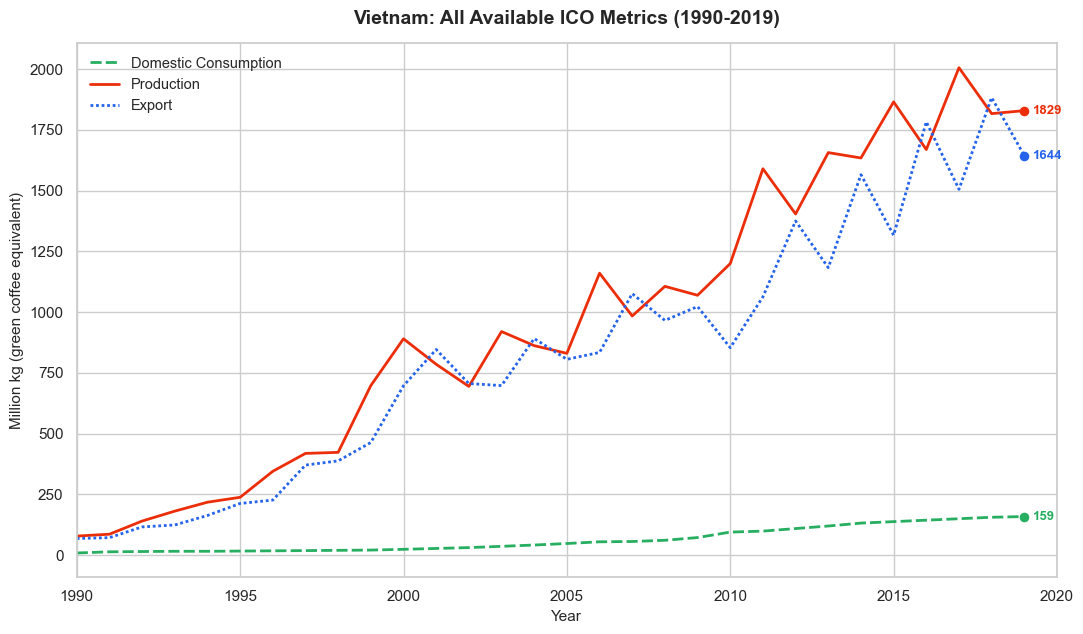

In [4]:
PALETTE = {"Production": "#EB2E09", "Domestic Consumption": "#27ae60", "Export": "#2563eb"}
DASHES = {"Production": "", "Domestic Consumption": (4, 1.5), "Export": (1, 1)}

fig, ax = plt.subplots(figsize=(11, 6.5))
sns.lineplot(data=plot_df, x="Year", y="value_million_kg",
             hue="Metric_label", style="Metric_label",
             ax=ax, linewidth=2, palette=PALETTE, dashes=DASHES)

ax.set_title("Vietnam: All Available ICO Metrics (1990-2019)", fontsize=14, fontweight="bold", pad=14)
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Million kg (green coffee equivalent)", fontsize=11)
ax.set_xlim(1990, 2020)  # <-- extended to 2020; no data point is plotted there
ax.legend(loc="upper left", frameon=False, fontsize=10.5, title="")

xticks = sorted(set(list(range(1990, 2020, 5)) + [2020]))
ax.set_xticks(xticks)

for label, color in PALETTE.items():
    last_row = plot_df[plot_df.Metric_label == label].sort_values("Year").iloc[-1]
    ax.scatter([last_row["Year"]], [last_row["value_million_kg"]], color=color, s=35, zorder=5)
    ax.annotate(f"{last_row['value_million_kg']:.0f}", xy=(last_row["Year"], last_row["value_million_kg"]),
                xytext=(6, 0), textcoords="offset points", fontsize=9.5, fontweight="bold",
                color=color, va="center")

plt.tight_layout()
plt.savefig("vietnam_all_metrics_through_2020.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

## Step 4 — Download the chart (Colab only)

In [5]:
try:
    from google.colab import files as _colab_files
    _colab_files.download("vietnam_all_metrics_through_2020.png")
except ImportError:
    print(f"Not in Colab — find it locally at: {Path('vietnam_all_metrics_through_2020.png').resolve()}")

Not in Colab — find it locally at: C:\Users\KrissW Laptop\Downloads\vietnam all metric 2\vietnam_all_metrics_through_2020.png
